# Implementando SARIMA

## Importando bibliotecas e o arquivo

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#nao roda do python 3.11 pra cima
# from pmdarima import auto_arima
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.express as px

In [17]:
data = pd.read_excel("./ITAIPU_MENSAL.xlsx", header=(1))
data.head()

,ANO,JAN,FEV,MAR,ABR,MAI,JUN,JUL,AGO,SET,OUT,NOV,DEZ
0,1931,16445,21715,23059,16537,12893,10841,8025,6059,7155,6709,6813,10737
1,1932,14357,16741,13818,11372,8441,8442,6648,5576,4857,7672,7152,13796
2,1933,16783,14300,10995,9232,7359,5637,4911,4193,3921,4685,4153,8045
3,1934,11072,9477,8966,7060,5358,4449,3633,2969,3417,3685,3117,8489
4,1935,12235,15428,14333,12001,8149,7727,5765,6837,6647,14279,8728,9094


## Transformação 

 Ajustando a base para uma coluna

In [18]:
#derretendo a base com pandas
data = data.melt(id_vars='ANO', var_name='MES', value_name='VAZAO')
data.head()

,ANO,MES,VAZAO
0,1931,JAN,16445
1,1932,JAN,14357
2,1933,JAN,16783
3,1934,JAN,11072
4,1935,JAN,12235


Fazendo o mapeamento dos meses e ajustando data

In [19]:
meses = {'JAN': '01', 'FEV':'02', 'MAR':'03', 'ABR':'04', 'MAI':'05', 'JUN':'06', 'JUL':'07', 'AGO':'08',
          'SET':'09', 'OUT':'10', 'NOV':'11', 'DEZ':'12'}
#mapeamento dos meses
data['MES'] = data['MES'].map(meses)
#unindo as oclunas de data
data['ANO-MES'] = data['ANO'].astype(str)+'-'+data['MES'].astype(str)
#convertendo para o tipo de data
data['ANO-MES'] = pd.to_datetime(data['ANO-MES'])
#ordenando os valores de forma ascendente
data = data[['ANO-MES','VAZAO']].sort_values(by=['ANO-MES'], ascending=True).reset_index(drop=True)
data.dtypes



ANO-MES    datetime64[ns]
VAZAO               int64
dtype: object

## Análise exploratória

Plot padrão da base

<Axes: xlabel='ANO-MES', ylabel='VAZAO'>

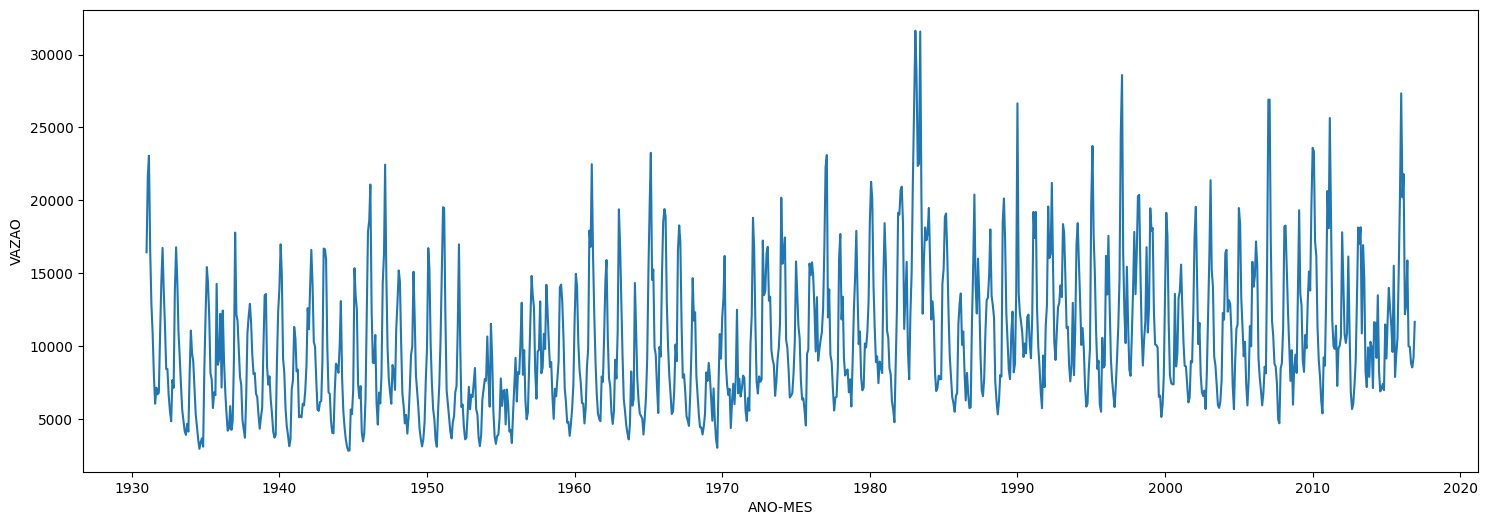

In [20]:
plt.figure(figsize=(18,6))
sns.lineplot(data=data, x='ANO-MES', y='VAZAO')

Plot da Tendência, sazonalidade e Resíduos

<Figure size 1000x600 with 0 Axes>

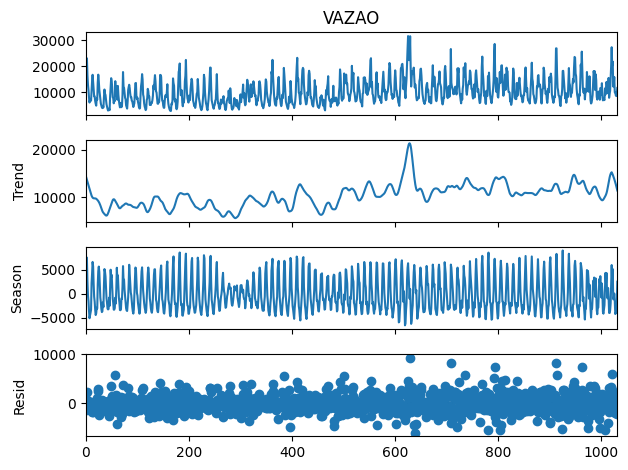

In [21]:
#definindo a vazao como indice para que dique melhor visualizavel graficamente
# data.set_index('ANO-MES', inplace=True)
# data_decomposto = seasonal_decompose(data['VAZAO'], model = 'additive', period=12)
stl = STL(data['VAZAO'], period=12)
data_decomposto = stl.fit()
plt.figure(figsize=(10,6))
data_decomposto.plot()
plt.show()

## Teste de estacionariedade

Hipótese nula: série não estacionária  
Intervalo de confiança: 0,95  
Significância: 0,05  
  
P-value > 0.05 = série não estacionária  
P-value <= 0.05 = série estacionária 

In [22]:
#descobrindo o p-valor
teste_adf_result = adfuller(data['VAZAO'].dropna())
print(f'O p-valor eh: {teste_adf_result[1]}')

O p-valor eh: 0.01257203646228371


## Visualizando Autocorrelação

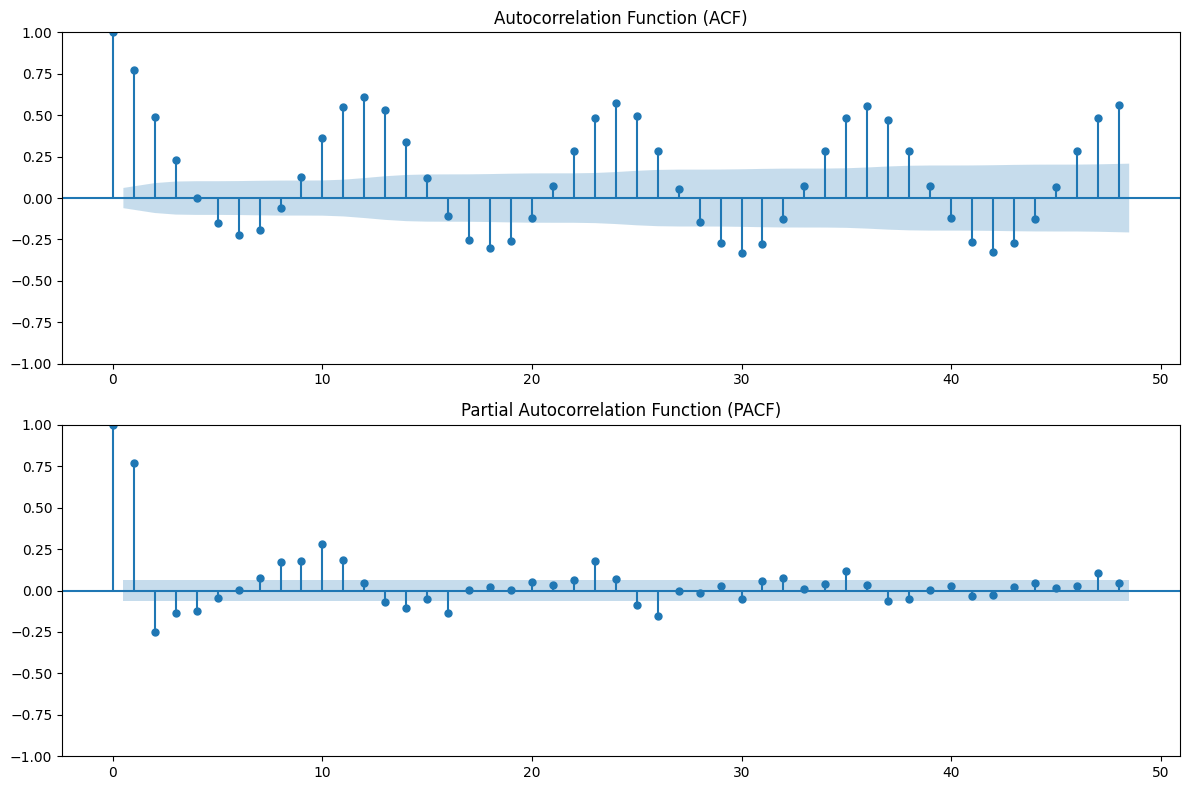

In [23]:
# definindo o numero de lags para visualizacao
n_lags = 48 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico ACF (para ordens q e Q)
plot_acf(data['VAZAO'], lags=n_lags, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# Gráfico PACF (para ordens p e P)
plot_pacf(data['VAZAO'], lags=n_lags, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

## Treinando o modelo

In [26]:

data_format = data.copy() 
data_format = data_format.set_index('ANO-MES').asfreq('MS')

# Converter para estrutura esperada pela statsforecast
df = data_format.reset_index().rename(columns={'ANO-MES':'ds', 'VAZAO':'y'})
df['unique_id'] = 'VAZAO'  
# Criar modelo AutoARIMA  
# equivalente ao seu antes: d=0, D=0, sazonalidade m=12
sf = StatsForecast(
    models=[AutoARIMA(
        d=0,
        D=0,
        max_p=3,
        max_q=3,
        max_P=1,
        max_Q=1,
        seasonal=True,
        season_length=12
    )],
    freq='M',
    n_jobs=1
)

sf.fit(df)  # 12 passos à frente
res = sf.predict(h=12)

print("\n=== Previsão ===")
print(res.tail(12))


=== Previsão ===
   unique_id         ds     AutoARIMA
0      VAZAO 2016-12-31  14518.368164
1      VAZAO 2017-01-31  13006.892578
2      VAZAO 2017-02-28  13796.153320
3      VAZAO 2017-03-31  11098.949219
4      VAZAO 2017-04-30  11257.249023
5      VAZAO 2017-05-31  12551.531250
6      VAZAO 2017-06-30  10380.661133
7      VAZAO 2017-07-31  10489.739258
8      VAZAO 2017-08-31   9896.106445
9      VAZAO 2017-09-30   9906.314453
10     VAZAO 2017-10-31   9953.820312
11     VAZAO 2017-11-30  10890.183594


c:\Python311\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Python311\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


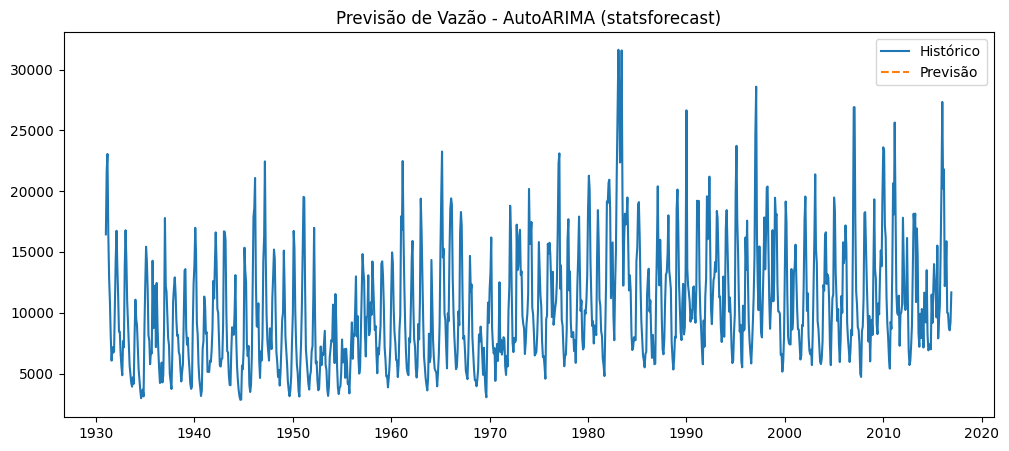

In [27]:
# Série histórica
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'], label='Histórico')

# Previsão
pred = res[res['unique_id']=='vazao']
plt.plot(pred['ds'], pred['AutoARIMA'], label='Previsão', linestyle='--')

plt.title("Previsão de Vazão - AutoARIMA (statsforecast)")
plt.legend()
plt.show()
